#### Import libraries

In [108]:
import math
import csv
import os
import copy
import numpy as np
import matplotlib.pyplot as plt

#### Import ProcessEmbryo and check it's working (by printing version date)

In [75]:
import ProcessEmbryo
print(ProcessEmbryo.__version__)

25.06.04


#### Run stack processing

In [76]:
# indicate a name of stack folder in the same directory or give an absolute path
stack_path = os.path.join(os.getcwd(), '230521_stack10')
# stack_path = os.path.abspath(MANUAL_ABSOLUTE_PATH_STRING)

**vvv Builds stack from raw extraction files - only run when needed! vvv**

In [77]:
force_reprocess_stack = False

if force_reprocess_stack or not os.path.isfile(os.path.join(stack_path, 'processed.stack')):
    processed_stack = ProcessEmbryo.process_stack(stack_path, channels = 2, channel_metric = "MeanIntensity_warp")
    ProcessEmbryo.save_stack(processed_stack)

#### Set global configs

In [78]:
frames_per_hour = 4 # frames-to-hours conversion factor
zero_division_epsilon = 0.0001 # constant preventing division by zero
division_line_style = ['black', (0, (2, 4)), 1] # plotting settings used for vertical division lines
deriv_thresh = 0.02 # threshold used in FUCCI spike calls

#### Load saved stack and make the Plots folder

In [79]:
stack = ProcessEmbryo.get_stack(os.path.join(stack_path, 'processed.stack'))
plot_path = os.path.join(stack_path, 'Plots')
if not os.path.exists(plot_path):
    os.mkdir(plot_path)

#### Check terminal cell IDs

In [80]:
IDs = []
for cell in stack[0]:
    IDs.append(cell[0][1])
IDs.sort()
print('Last frame:', stack[0][0][0][0])
print('Leaf cell IDs:', IDs)
print('Total reconstructed lineages:',len(IDs))

Last frame: 124
Leaf cell IDs: [4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 52, 53, 54, 199, 200, 201, 202, 203, 204, 205, 206, 207, 210, 211, 212]
Total reconstructed lineages: 60


#### Define supporting functions (will be moved into the main package later)

In [81]:
def cell_exists(search_stack_track, cell_ID, echo = True): # returns whether queried cell exists in the stack
    found = False
    for pair in search_stack_track:
        found = (pair[0] == cell_ID) or (pair[1] == cell_ID)
        if found:
            break
    if not found and echo:
        print('Cell ' + str(cell_ID[0]) + '_' + str(cell_ID[1]) + ' not found in the tree')
    return found


def minimal_rectangle(N):
    """
    Calculates the dimensions of a minimal X by Y rectangular grid that can contain N elements
    """
    X = int(round(math.sqrt(N), 0))
    Y = N // X
    
    if N % X > 0:
        Y += 1
    
    return X, Y


def colsel_by_fate(fate_name): # returns color string based of fate name
    if fate_name == 'ICM':
        color = 'purple'
    elif fate_name == 'TE':
        color = 'brown'
    else:
        color = 'black'
        print('Fate-based color selection failed, defaulted to ' + color)
    return color


def colsel_by_signal(signal_name): # returns color string based of signal name
    if signal_name == 'histone':
        color = 'darkgrey'
    elif signal_name == 'fucci':
        color = 'darkred'
    else:
        color = 'black'
        print('Fate-based color selection failed, defaulted to ' + color)
    return color


def smoothen_trace(raw_trace, method = "average", kernel_size = 1): # returns a smoothened version of a signal trace
    if kernel_size == 0:
        return raw_trace
    
    else:
        temp_trace = []
        for i in range(kernel_size):
            temp_trace.append(math.nan)
        for point in raw_trace:
            temp_trace.append(point)
        for i in range(kernel_size):
            temp_trace.append(math.nan)

        out_trace = []
        for i in range(kernel_size, len(raw_trace) + kernel_size, 1):
            cur_val = 0
            cur_kern = 0
            
            if method == "average":
                for j in range(i - kernel_size, i + kernel_size + 1, 1):
                    if not math.isnan(temp_trace[j]):
                        kern_weight = 1
                        cur_val += kern_weight * temp_trace[j]
                        cur_kern += kern_weight
                out_trace.append(cur_val / cur_kern)
                
            elif method == "inverse":
                for j in range(i - kernel_size, i + kernel_size + 1, 1):
                    if not math.isnan(temp_trace[j]):
                        kern_weight = 1 / (abs(i-j) + 1)
                        cur_val += kern_weight * temp_trace[j]
                        cur_kern += kern_weight
                out_trace.append(cur_val / cur_kern)
            
            else:
                raise ValueError("Invalid smoothing method requested")

        return out_trace

#### Plot signal intensities for both channels in all cells

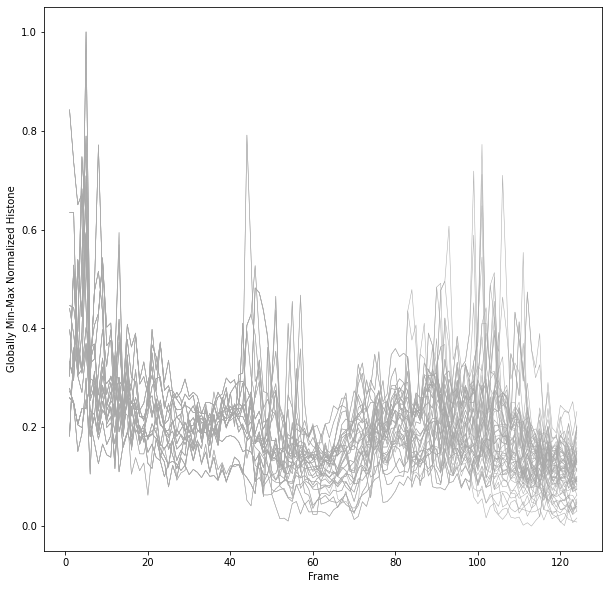

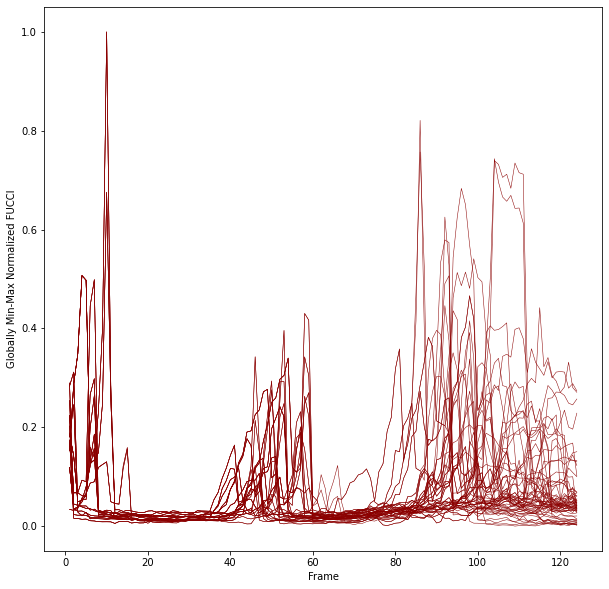

In [82]:
stack_name = stack[2][3][0]
stack_data = stack[0]
channels = len(stack[2][2][0])
channel_mins = stack[2][2][0]
channel_maxs = stack[2][2][1]

plot_channels = []
for c in range(channels):
    channel_tmp = []
    for lineage in stack_data:
        lineage_tmp = []
        for cell in lineage[1]:
            if (c + 5) <= (len(cell) - 1):
                temp = [cell[0], cell[c + 5]]
                lineage_tmp.append(temp)
        channel_tmp.append(lineage_tmp)
    plot_channels.append(channel_tmp)

plt.figure(figsize=(10, 10))
histone = plot_channels[0]
histone_traces = []
for trace in histone:
    temp_x = []
    temp_y = []
    for cell in trace:
        temp_x.append(cell[0])
        temp_y.append((cell[1] - channel_mins[0]) / (channel_maxs[0] - channel_mins[0] + zero_division_epsilon))
    histone_traces.append([temp_x, temp_y])
    
for trace in histone_traces:
    plt.plot(trace[0], trace[1], colsel_by_signal('histone'), linewidth = 0.5)
    
plt.ylabel("Globally Min-Max Normalized Histone")
plt.xlabel("Frame")
plt.show()

plt.figure(figsize=(10, 10))
fucci = plot_channels[1]
fucci_traces = []
for trace in fucci:
    temp_x = []
    temp_y = []
    for cell in trace:
        temp_x.append(cell[0])
        temp_y.append((cell[1] - channel_mins[1]) / (channel_maxs[1] - channel_mins[1] + zero_division_epsilon))
    fucci_traces.append([temp_x, temp_y])
    
for trace in fucci_traces:
    plt.plot(trace[0], trace[1], color = colsel_by_signal('fucci'), linewidth = 0.5)
    
plt.ylabel("Globally Min-Max Normalized FUCCI")
plt.xlabel("Frame")
plt.show()

#### Print dynamic ranges

In [83]:
range_mins = stack[2][2][0]
range_maxs = stack[2][2][1]
for i in range(len(range_mins)):
    if i == 0:
        print('Histone:')
    else:
        print(f'Signal_{i}:')
    print(f'[{range_mins[i]:.2f} - {range_maxs[i]:.2f}]')

Histone:
[122.07 - 200.26]
Signal_1:
[117.93 - 240.55]


#### Get manual fate calls

In [84]:
# get the list of cells with called fate
cells_called = []
with open(os.path.join(stack_path, 'fate_calls.csv'), newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',', quotechar='|')
    for row in reader:
        s1 = row[0].replace("'", '')
        s1_1 = int(s1[0:s1.find('_')])
        s1_2 = int(s1[s1.find('_') + 1 : len(s1)])
        if cell_exists(stack[1][0], [s1_1, s1_2]):
            cells_called.append([s1_1, s1_2, row[1]])
cells_called = np.array(cells_called)

# make a list of called fate
fate = []
for i in range(len(cells_called)):
    if cells_called[i][2] not in fate:
        fate.append(cells_called[i][2])

#### List all fates and cells with fate calls

In [85]:
print(fate)
print(cells_called)

['ICM', 'TE']
[['124' '12' 'ICM']
 ['124' '42' 'ICM']
 ['124' '34' 'ICM']
 ['124' '54' 'ICM']
 ['124' '30' 'ICM']
 ['124' '203' 'ICM']
 ['124' '205' 'ICM']
 ['124' '5' 'ICM']
 ['124' '17' 'ICM']
 ['124' '26' 'ICM']
 ['124' '21' 'ICM']
 ['124' '7' 'ICM']
 ['124' '35' 'ICM']
 ['124' '11' 'ICM']
 ['124' '9' 'ICM']
 ['124' '6' 'TE']
 ['124' '204' 'TE']
 ['124' '29' 'TE']
 ['124' '33' 'TE']
 ['124' '4' 'TE']
 ['124' '23' 'TE']
 ['124' '206' 'TE']
 ['124' '199' 'TE']
 ['124' '201' 'TE']
 ['124' '27' 'TE']
 ['124' '10' 'TE']
 ['124' '200' 'TE']
 ['124' '15' 'TE']
 ['124' '20' 'TE']
 ['124' '32' 'TE']
 ['124' '36' 'TE']
 ['124' '49' 'TE']
 ['124' '210' 'TE']
 ['124' '47' 'TE']
 ['124' '43' 'TE']
 ['124' '8' 'TE']
 ['124' '22' 'TE']
 ['124' '202' 'TE']
 ['124' '211' 'TE']
 ['124' '53' 'TE']
 ['124' '50' 'TE']
 ['124' '14' 'TE']
 ['124' '45' 'TE']
 ['124' '24' 'TE']
 ['124' '40' 'TE']
 ['124' '25' 'TE']
 ['124' '52' 'TE']
 ['124' '19' 'TE']
 ['124' '48' 'TE']
 ['124' '38' 'TE']
 ['124' '37' 'TE'

#### Reconstruct and process fate-called cells

In [86]:
fate_data = []

for p in fate:
    temp_cells = []

    for i in range(len(cells_called)):
        if cells_called[i][2] == p:
            temp_cells.append([int(cells_called[i][0]), int(cells_called[i][1])])

    temp_data = []
    for cell in temp_cells:
        # reconstruct lineage from leaf
        temp_lin = ProcessEmbryo.lineage_reconstruct(stack[1][0], stack[2][0], cell[0], cell[1])
        # extract reconstructed lineage
        temp_data.append([cell, ProcessEmbryo.lineage_express(ProcessEmbryo.lineage_transform(temp_lin[0]), stack[1][1]), temp_lin[1]])

    fate_data.append([p, temp_data])

print("Fate-called data reconstructed")

Fate-called data reconstructed


In [87]:
show_examples = False

if show_examples:
    # print first fate name
    print(fate_data[0][0])
    # print first cell's [frame, ID]
    print(fate_data[0][1][0][0])
    # print cell's first frame data [frame, ID, centroidX, cenbtroidY, centroidZ, histone, fucci]
    print(fate_data[0][1][0][1][0])
    # print cell's division frames as a list of [frame, ID]
    print(fate_data[0][1][0][2])

#### Plot <u>globally</u> min-max normalized FUCCI traces

Showing plots for ICM


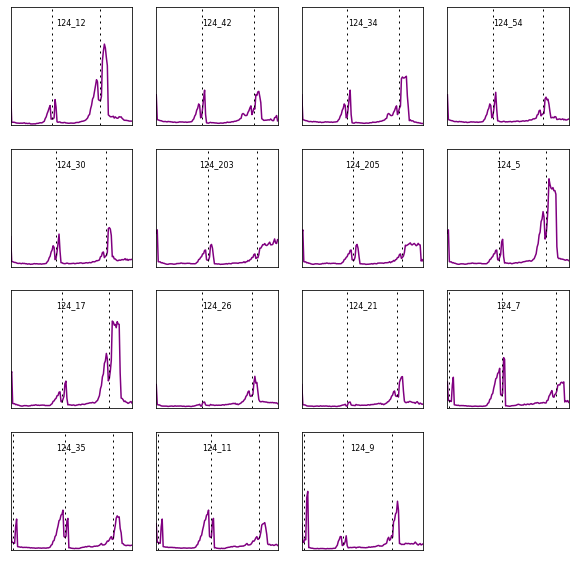

Showing plots for TE


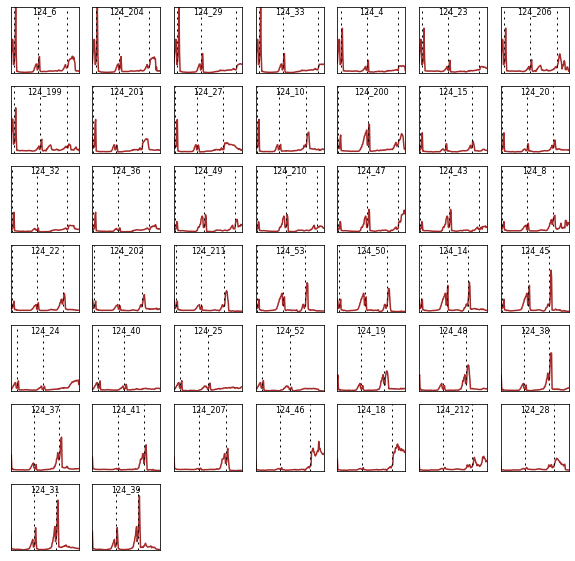

In [88]:
titles = True # add leaf cell IDs as plot titles
div_lines = True # add division lines (from lineage tree)

cnt = 0
for p in fate:
    plot_data = []
    if titles:
        names = []
    if div_lines:
        divisions = []
        
    for cell in fate_data[cnt][1]:
        frame = []
        fucci = []
        for f in cell[1]:
            frame.append(f[0])
            fucci.append(f[6])
        plot_data.append([frame, fucci])
        if titles:
            names.append(str(cell[0][0]) + '_' + str(cell[0][1]))
        if div_lines:
            divisions.append(cell[2])
    
    print('Showing plots for ' + fate[cnt])
    
    plt.figure(figsize=(10, 10))
    N, M = minimal_rectangle(len(plot_data))
    for i in range(len(plot_data)):
        plt.subplot(N, M, i + 1)
        plt.xticks([])
        plt.yticks([])
        if titles:
            plt.title(names[i], fontsize = 8, y = 0.8)
        plt.ylim(0, 1)
        plt.xlim(stack[2][1][0], stack[2][1][1])
        plt.plot(plot_data[i][0], (plot_data[i][1] - stack[2][2][0][1])/(stack[2][2][1][1] - stack[2][2][0][1] + zero_division_epsilon), c=colsel_by_fate(fate[cnt]))
        if div_lines:
            for division in divisions[i]:
                plt.axvline(x = division[0], color = division_line_style[0], linestyle = division_line_style[1], linewidth = division_line_style[2])
    
    plt.show()
    cnt += 1

#### Plot <u>individually</u> min-max normalized FUCCI traces

Showing plots for ICM


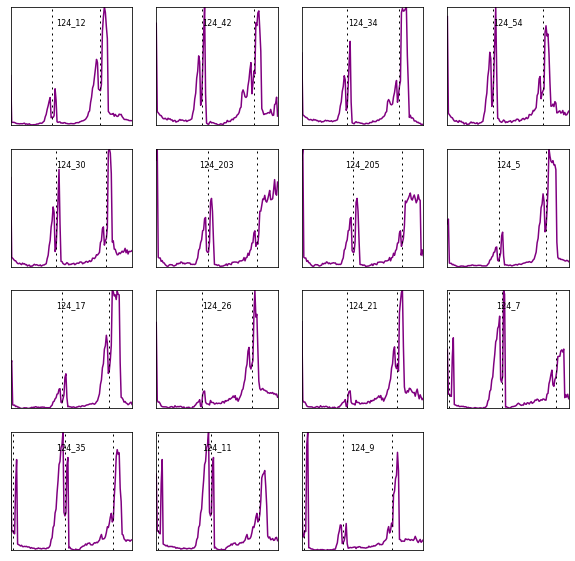

Showing plots for TE


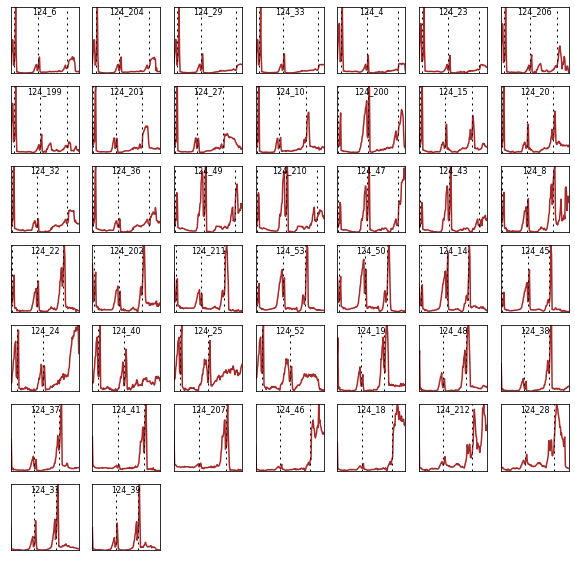

In [89]:
titles = True # add leaf cell IDs as plot titles
div_lines = True # add division lines (from lineage tree)
save_data = True # save computed traces for further analysis

if save_data:
    indiv_norm_traces = []

cnt = 0
for p in fate:
    plot_data = []
    if titles:
        names = []
    if div_lines:
        divisions = []
        
    for cell in fate_data[cnt][1]:
        frame = []
        fucci = []
        fucci_min = stack[2][2][1][1] + 1
        fucci_max = stack[2][2][0][1] - 1
        for f in cell[1]:
            frame.append(f[0])
            fucci.append(f[6])
            if f[6] > fucci_max:
                fucci_max = f[6]
            if f[6] < fucci_min:
                fucci_min = f[6]
                
        fucci_out = []
        for f in fucci:
            fucci_out.append((f - fucci_min)/(fucci_max - fucci_min + zero_division_epsilon))
            
        plot_data.append([frame, fucci_out])
        if titles:
            names.append(str(cell[0][0]) + '_' + str(cell[0][1]))
        if div_lines:
            divisions.append(cell[2])
    
    if save_data:
        tmp = []
        tmp.append(plot_data)
        if titles:
            tmp.append(names)
        if div_lines:
            tmp.append(divisions)
        indiv_norm_traces.append([fate[cnt], tmp])
    
    print('Showing plots for ' + fate[cnt])
    
    plt.figure(figsize=(10, 10))
    N, M = minimal_rectangle(len(plot_data))
    for i in range(len(plot_data)):
        plt.subplot(N, M, i + 1)
        plt.xticks([])
        plt.yticks([])
        if titles:
            plt.title(names[i], fontsize = 8, y = 0.8)
        plt.ylim(0, 1)
        plt.xlim(stack[2][1][0], stack[2][1][1])
        plt.plot(plot_data[i][0], smoothen_trace(plot_data[i][1], method = 'inverse', kernel_size = 0), c = colsel_by_fate(fate[cnt]))
        if div_lines:
            for division in divisions[i]:
                plt.axvline(x = division[0], color = division_line_style[0], linestyle = division_line_style[1], linewidth = division_line_style[2])
            
    plt.show()
    cnt += 1

#### Plot <u>individually</u> min-max normalized FUCCI <u>derivative</u> traces 

Showing plots for ICM


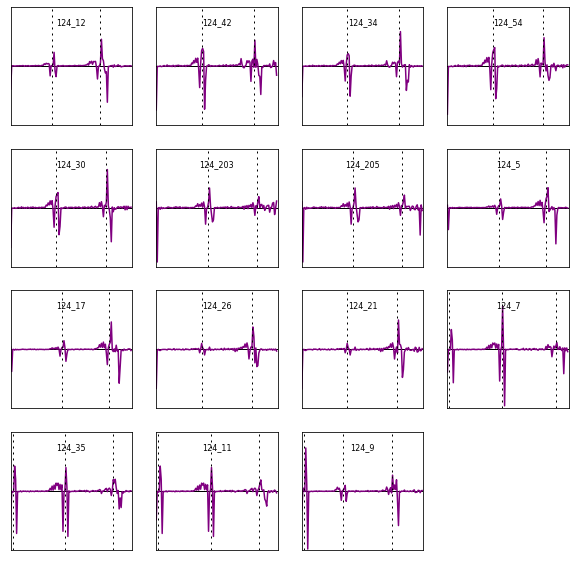

Showing plots for TE


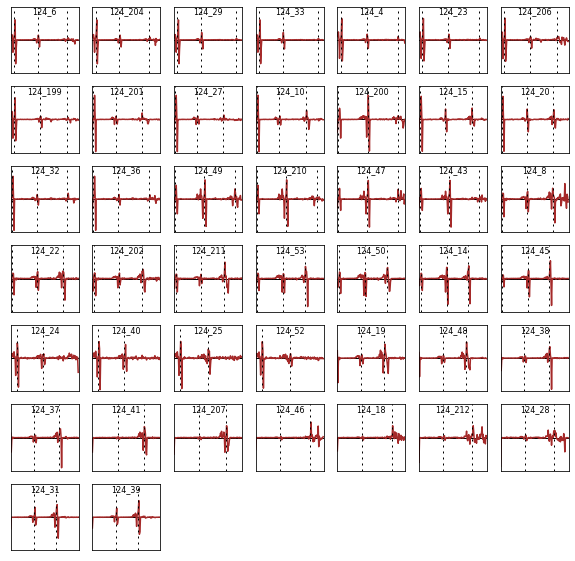

In [90]:
titles = True # add leaf cell IDs as plot titles
div_lines = True # add division lines (from lineage tree)
save_data = True # save computed traces for further analysis

if save_data:
    indiv_norm_derivs = []

cnt = 0
for p in fate:
    plot_data = []
    if titles:
        names = []
    if div_lines:
        divisions = []
        
    for cell in fate_data[cnt][1]:
        frame = []
        fucci = []
        fucci_min = stack[2][2][1][1] + 1
        fucci_max = stack[2][2][0][1] - 1
        for f in cell[1]:
            frame.append(f[0])
            fucci.append(f[6])
            if f[6] > fucci_max:
                fucci_max = f[6]
            if f[6] < fucci_min:
                fucci_min = f[6]
                
        fucci_der = []
        for i in range(len(fucci) - 1):
            temp1 = (fucci[i+1] - fucci_min)/(fucci_max - fucci_min + zero_division_epsilon)
            temp2 = (fucci[i] - fucci_min)/(fucci_max - fucci_min + zero_division_epsilon)
            fucci_der.append(temp1 - temp2)
        trash = frame.pop()
        
        plot_data.append([frame, fucci_der])
        if titles:
            names.append(str(cell[0][0]) + '_' + str(cell[0][1]))
        if div_lines:
            divisions.append(cell[2])
    
    if save_data:
        tmp = []
        tmp.append(plot_data)
        if titles:
            tmp.append(names)
        if div_lines:
            tmp.append(divisions)
        indiv_norm_derivs.append([fate[cnt], tmp])
    
    print('Showing plots for ' + fate[cnt])
    
    plt.figure(figsize=(10, 10))
    N, M = minimal_rectangle(len(plot_data))
    for i in range(len(plot_data)):
        plt.subplot(N, M, i + 1)
        plt.xticks([])
        plt.yticks([])
        if titles:
            plt.title(names[i], fontsize = 8, y = 0.8)
        plt.ylim(-1, 1)
        plt.xlim(stack[2][1][0], stack[2][1][1])
        plt.axhline(y = 0, color = 'k', linewidth = 1)
        plt.plot(plot_data[i][0], smoothen_trace(plot_data[i][1], method = 'inverse', kernel_size = 0), c = colsel_by_fate(fate[cnt]))
        if div_lines:
            for division in divisions[i]:
                plt.axvline(x = division[0], color = division_line_style[0], linestyle = division_line_style[1], linewidth = division_line_style[2])
        
    plt.show()
    cnt += 1

In [91]:
show_examples = False

if show_examples:
    # print fate name
    print(indiv_norm_traces[0][0])
    # print first cell's frames
    print(indiv_norm_traces[0][1][0][0][0])
    # print first cell's individually normalized fucci intensities
    print(indiv_norm_traces[0][1][0][0][1])
    # print leaf cell names
    print(indiv_norm_traces[0][1][1])
    # print cell divisions
    print(indiv_norm_traces[0][1][2])

#### Plot a given cell's FUCCI trace along the derivative trace

In [92]:
def plot_cell_double_trace(trace1, trace2, cell_ID, smoothing = ['inverse', 0], savefig = [False, 'null', 'png']): # plots individually normalized trace and the derivative trace of quiried cell
    fate_index = -1
    cell_index = -1
    cell_name = str(cell_ID[0]) + '_' + str(cell_ID[1])
    
    cnt = 0
    for fates in trace1:
        if cell_name in fates[1][1]:
            fate_index = cnt
            cell_index = fates[1][1].index(cell_name)
        cnt += 1
    
    plt.figure(figsize=(10, 10))
    
    plt.subplot(2, 1, 1)
    plt.plot(trace1[fate_index][1][0][cell_index][0], smoothen_trace(trace1[fate_index][1][0][cell_index][1], method = smoothing[0], kernel_size = smoothing[1]), c = colsel_by_fate(fate[fate_index]), linewidth = 3)
    for division in trace1[fate_index][1][2][cell_index]:
        plt.axvline(x = division[0], color = division_line_style[0], linestyle = division_line_style[1], linewidth = division_line_style[2])
    plt.ylim(0, 1)
    plt.xlim(stack[2][1][0], stack[2][1][1])
    plt.ylabel('Individually Min-MAx Normallized FUCCI')
    
    plt.subplot(2, 1, 2)
    plt.plot(trace2[fate_index][1][0][cell_index][0], smoothen_trace(trace2[fate_index][1][0][cell_index][1], method = smoothing[0], kernel_size = smoothing[1]), c = colsel_by_fate(fate[fate_index]), linewidth = 3)
    for division in trace2[fate_index][1][2][cell_index]:
        plt.axvline(x = division[0], color = division_line_style[0], linestyle = division_line_style[1], linewidth = division_line_style[2])
    plt.axhline(y = 0, color = 'k', linewidth = 1)
    plt.ylim(-1, 1)
    plt.xlim(stack[2][1][0], stack[2][1][1])
    plt.ylabel('Individually Min-MAx Normallized FUCCI Derivative')
    plt.xlabel('Frame')
    plt.title('Cell ' + cell_name + ' (' + fate[fate_index] + ')', fontsize = 15, y = 1.025)
    
    # save out the plots
    if savefig[0]:
        temp_name = fate[fate_index] + '_' + cell_name + '_dualplot.' + savefig[2]
        plt.savefig(os.path.join(savefig[1], temp_name))

    plt.show()

#### Individually min-max normalized raw and derivative trace plotting

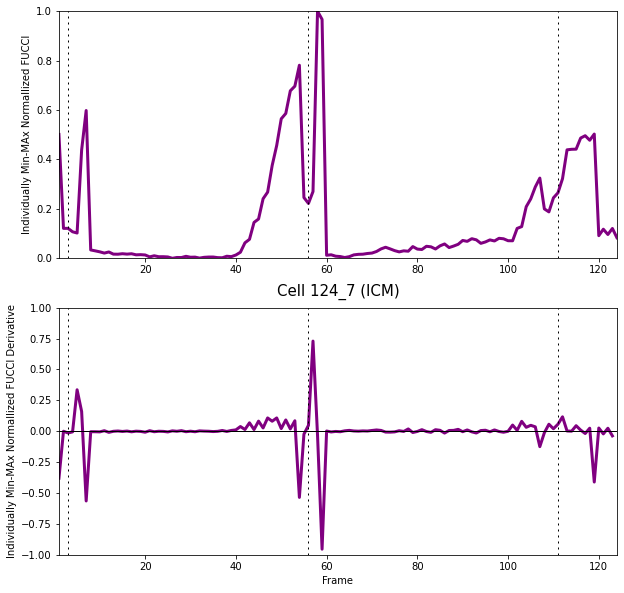

In [93]:
target_cell_ID = [124, 7] # desired cell's [frame, ID]
plot_cell_double_trace(indiv_norm_traces, indiv_norm_derivs, target_cell_ID)

#### Inverse kernel smoothed trace plotting

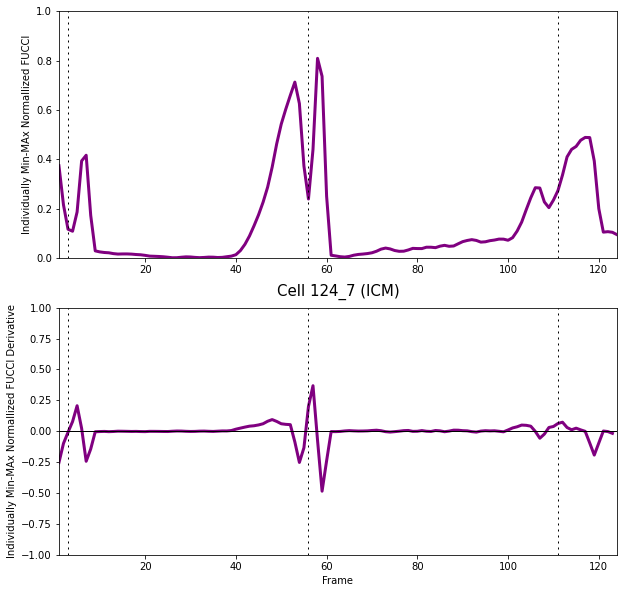

In [94]:
target_cell_ID = [124, 7] # desired cell's [frame, ID]
plot_cell_double_trace(indiv_norm_traces, indiv_norm_derivs, target_cell_ID, smoothing = ['inverse', 1], savefig = [False, plot_path, 'svg'])

#### Derivative destribution calculation and plotting

In [95]:
# save out all derivative measurements
all_derivs = []
for indiv_fate in indiv_norm_derivs:
    for cell in indiv_fate[1][0]:
        for point in cell[1]:
            all_derivs.append(point)

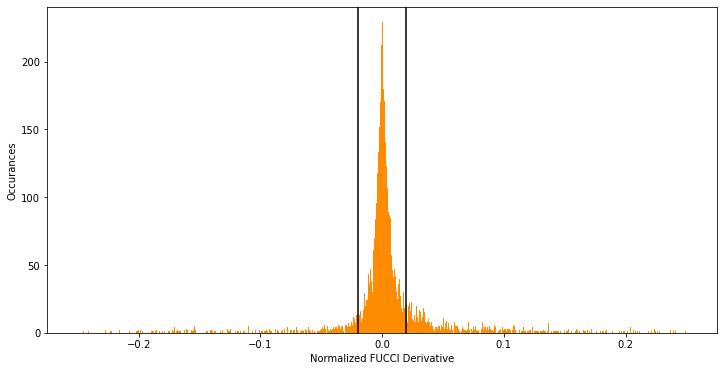

In [96]:
save_div_dis = True # save the derivative distribution plot 

# make the derivative distribution plot
plt.figure(figsize=(12, 6))
plt.hist(all_derivs, bins=1000, range=(-0.25, 0.25), color='darkorange')
plt.axvline(x = -1 * deriv_thresh, c = 'black')
plt.axvline(x = deriv_thresh, c = 'black')
plt.xlabel('Normalized FUCCI Derivative')
plt.ylabel('Occurances')

if save_div_dis:
    plt.savefig(os.path.join(plot_path, 'deriv_dist.svg'))

#### Annotate divisions and traces

In [97]:
def annotate_division(raw_traces, deriv_traces, cell_ID, division_round = 64, smoothing = ['inverse', 1], makeplots = False, savefig = [False, 'null', 'png']):
    # find and format data of the queried cell
    fate_index = -1
    cell_index = -1
    cell_name = str(cell_ID[0]) + '_' + str(cell_ID[1])
    
    cnt = 0
    for fates in raw_traces:
        if cell_name in fates[1][1]:
            fate_index = cnt
            cell_index = fates[1][1].index(cell_name)
        cnt += 1
    
    temp_frames = raw_traces[fate_index][1][0][cell_index][0]
    temp_smooth = smoothen_trace(raw_traces[fate_index][1][0][cell_index][1], method = smoothing[0], kernel_size = smoothing[1])
    temp_derivs = smoothen_trace(deriv_traces[fate_index][1][0][cell_index][1], method = smoothing[0], kernel_size = smoothing[1])
    temp_divs = raw_traces[fate_index][1][2][cell_index]
    
    # annotate trace features
    if division_round == 64:
        setback = 1
    elif division_round == 32:
        setback = 2
    else:
        setback = 3
    
    if temp_divs[len(temp_divs) - 1][0] > 120:
        setback += 1
    
    if setback > len(temp_divs):
        print('ERROR: No requested division')
        return [-1, -1, -1, -1]
    
    div_frame = temp_divs[len(temp_divs) - setback][0]
    div_frame_index = temp_frames.index(div_frame)
    
    permit = 20
    pre_div_peak = [-1, -999]
    pre_div_dip = [-1, 999]
    for i in range(max(div_frame_index - permit, 0), div_frame_index - 1, 1):
        if temp_smooth[i] > pre_div_peak[1]:
            pre_div_peak[0] = i
            pre_div_peak[1] = temp_smooth[i]
        if temp_derivs[i] < pre_div_dip[1]:
            pre_div_dip[0] = i
            pre_div_dip[1] = temp_derivs[i]
    
    post_div_peak = [-1, -999]
    post_div_dip = [-1, 999]
    for i in range(div_frame_index + 1, min(div_frame_index + permit, len(temp_frames) - 1), 1):
        if temp_smooth[i] > post_div_peak[1]:
            post_div_peak[0] = i
            post_div_peak[1] = temp_smooth[i]
        if temp_derivs[i] < post_div_dip[1]:
            post_div_dip[0] = i
            post_div_dip[1] = temp_derivs[i]
    
    mitotic_dip = [-1, 999]
    for i in range(pre_div_peak[0], post_div_peak[0], 1):
        if temp_smooth[i] < mitotic_dip[1]:
            mitotic_dip[0] = i
            mitotic_dip[1] = temp_smooth[i]
    
    pre_div_thresh = [-1, False]
    i = max(div_frame_index - permit, 0)
    while not pre_div_thresh[1] and i < div_frame_index:
        if temp_derivs[i] >= deriv_thresh:
            pre_div_thresh[1] = True
            pre_div_thresh[0] = i
        i += 1
    
    post_div_thresh = [-1, False]
    i =  post_div_dip[0]
    while not post_div_thresh[1] and i < min(div_frame_index + permit, len(temp_derivs) - 1):
        if temp_derivs[i] >= -1 * deriv_thresh:
            post_div_thresh[1] = True
            post_div_thresh[0] = i
        i += 1
    
    # make annotated plots
    if makeplots:
        plt.figure(figsize=(10, 10))

        plt.subplot(2, 1, 1)
        plt.plot(temp_frames, temp_smooth, c = colsel_by_fate(fate[fate_index]), marker='o', markersize=3, linestyle ='--', linewidth = 1)

        # draw tree-based division lines
        for division in temp_divs:
            plt.axvline(x = division[0], color = division_line_style[0], linestyle = division_line_style[1], linewidth = division_line_style[2])
        # draw annotated events
        plt.axvline(x = temp_frames[pre_div_peak[0]], c = 'green')
        #plt.axvline(x = temp_frames[pre_div_dip[0] + 1], c = 'red') 
        plt.axvline(x = temp_frames[post_div_peak[0]], c = 'green') 
        #plt.axvline(x = temp_frames[post_div_dip[0] + 1], c = 'red') 
        if pre_div_thresh[1]:
            plt.axvline(x = temp_frames[pre_div_thresh[0]], c = 'blue')
        if post_div_thresh[1]:
            plt.axvline(x = temp_frames[post_div_thresh[0]], c = 'blue')
        plt.axvline(x = temp_frames[mitotic_dip[0]], c = 'yellow')

        plt.ylim(0, 1)
        plt.xlim(stack[2][1][0], stack[2][1][1])
        plt.ylabel('Individually Min-Max Normallized FUCCI')

        plt.subplot(2, 1, 2)
        plt.plot(deriv_traces[fate_index][1][0][cell_index][0], temp_derivs, c = colsel_by_fate(fate[fate_index]), marker='o', markersize=3, linestyle ='--', linewidth = 1)

        # draw tree-based division lines
        for division in temp_divs:
            plt.axvline(x = division[0], color = division_line_style[0], linestyle = division_line_style[1], linewidth = division_line_style[2])
        # draw annotated events
        #plt.axvline(x = temp_frames[pre_div_peak[0] - 1], c = 'green')
        plt.axvline(x = temp_frames[pre_div_dip[0]], c = 'red') 
        #plt.axvline(x = temp_frames[post_div_peak[0] - 1], c = 'green') 
        plt.axvline(x = temp_frames[post_div_dip[0]], c = 'red')
        if pre_div_thresh[1]:
            plt.axvline(x = temp_frames[pre_div_thresh[0]], c = 'blue')
        if post_div_thresh[1]:
            plt.axvline(x = temp_frames[post_div_thresh[0]], c = 'blue')

        plt.axhline(y = 0, color = 'k', linewidth = 1)
        plt.axhline(y = deriv_thresh, color = 'k', linewidth = 0.5, linestyle = ':')
        plt.axhline(y = -1 * deriv_thresh, color = 'k', linewidth = 0.5, linestyle = ':')
        plt.axhline(y = 0, color = 'k', linewidth = 1)
        plt.ylim(-1, 1)
        plt.xlim(stack[2][1][0], stack[2][1][1])
        plt.ylabel('Individually Min-Max Normallized FUCCI Derivative')
        plt.xlabel('Frame')
        plt.title('Cell ' + cell_name + ' (' + fate[fate_index] + ')', fontsize = 15, y = 1.025)

        # save out the plots
        if savefig[0]:
            temp_name = fate[fate_index] + '_' + cell_name + '_labeled_' + str(division_round) + '.' + savefig[2]
            plt.savefig(os.path.join(savefig[1], temp_name))

        plt.show()
    
    return [div_frame, temp_frames[pre_div_thresh[0]], temp_frames[mitotic_dip[0]], temp_frames[post_div_thresh[0]]]

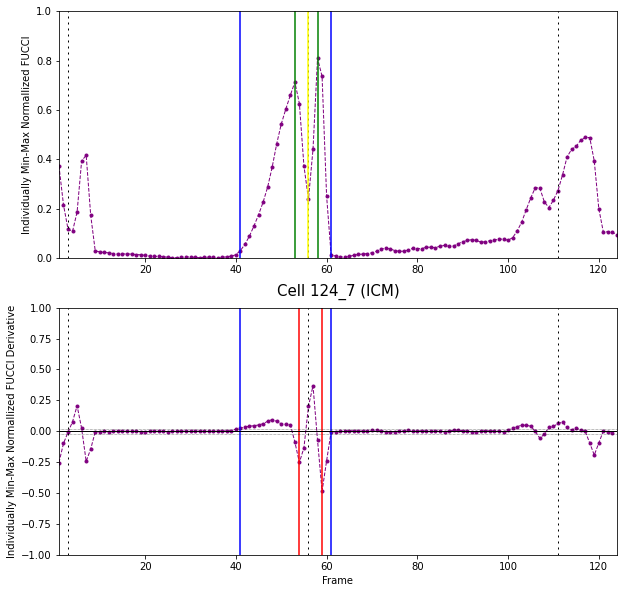

In [98]:
test_calls = annotate_division(indiv_norm_traces, indiv_norm_derivs, [124, 7], division_round = 32, makeplots = True, savefig = [False, plot_path, 'svg'])

In [99]:
make_all_div_plots = False # make plots for all cells and divisions

if make_all_div_plots:
    for indiv_fate in fate_data:
        for cell in indiv_fate[1]:
            temp_calls = annotate_division(indiv_norm_traces, indiv_norm_derivs, cell[0], division_round = 16, makeplots = True, savefig = [True, plot_path, 'png'])
            temp_calls = annotate_division(indiv_norm_traces, indiv_norm_derivs, cell[0], division_round = 32, makeplots = True, savefig = [True, plot_path, 'png'])
            temp_calls = annotate_division(indiv_norm_traces, indiv_norm_derivs, cell[0], division_round = 64, makeplots = True, savefig = [True, plot_path, 'png'])

In [100]:
def annotate_trace(raw_traces, deriv_traces, cell_ID, smoothing = ['inverse', 1], makeplots = False, savefig = [False, 'null', 'png']):
    # find and format data of the queried cell
    fate_index = -1
    cell_index = -1
    cell_name = str(cell_ID[0]) + '_' + str(cell_ID[1])
    
    cnt = 0
    for fates in raw_traces:
        if cell_name in fates[1][1]:
            fate_index = cnt
            cell_index = fates[1][1].index(cell_name)
        cnt += 1
    
    temp_frames = raw_traces[fate_index][1][0][cell_index][0]
    temp_smooth = smoothen_trace(raw_traces[fate_index][1][0][cell_index][1], method = smoothing[0], kernel_size = smoothing[1])
    temp_derivs = smoothen_trace(deriv_traces[fate_index][1][0][cell_index][1], method = smoothing[0], kernel_size = smoothing[1])
    temp_divs = raw_traces[fate_index][1][2][cell_index]
    
    # annotate trace features
    pre_threshs = []
    mitotic_dips = []
    post_threshs = []
    
    for a_div in temp_divs:
        div_frame = a_div[0]
        div_frame_index = temp_frames.index(div_frame)

        permit = 20
        pre_div_peak = [-1, -999]
        pre_div_dip = [-1, 999]
        for i in range(max(div_frame_index - permit, 0), div_frame_index - 1, 1):
            if temp_smooth[i] > pre_div_peak[1]:
                pre_div_peak[0] = i
                pre_div_peak[1] = temp_smooth[i]
            if temp_derivs[i] < pre_div_dip[1]:
                pre_div_dip[0] = i
                pre_div_dip[1] = temp_derivs[i]

        post_div_peak = [-1, -999]
        post_div_dip = [-1, 999]
        for i in range(div_frame_index + 1, min(div_frame_index + permit, len(temp_frames) - 1), 1):
            if temp_smooth[i] > post_div_peak[1]:
                post_div_peak[0] = i
                post_div_peak[1] = temp_smooth[i]
            if temp_derivs[i] < post_div_dip[1]:
                post_div_dip[0] = i
                post_div_dip[1] = temp_derivs[i]

        mitotic_dip = [-1, 999]
        for i in range(pre_div_peak[0], post_div_peak[0], 1):
            if temp_smooth[i] < mitotic_dip[1]:
                mitotic_dip[0] = i
                mitotic_dip[1] = temp_smooth[i]

        pre_div_thresh = [-1, False]
        i = max(div_frame_index - permit, 0)
        while not pre_div_thresh[1] and i < div_frame_index:
            if temp_derivs[i] >= deriv_thresh:
                pre_div_thresh[1] = True
                pre_div_thresh[0] = i
            i += 1

        post_div_thresh = [-1, False]
        i =  post_div_dip[0]
        while not post_div_thresh[1] and i < min(div_frame_index + permit, len(temp_derivs) - 1):
            if temp_derivs[i] >= -1 * deriv_thresh:
                post_div_thresh[1] = True
                post_div_thresh[0] = i
            i += 1
        
        pre_threshs.append(pre_div_thresh)
        mitotic_dips.append(mitotic_dip)
        post_threshs.append(post_div_thresh)
    
    # format annotations
    out_pre_threshs = []
    for obj in pre_threshs:
        if obj[1]:
            out_pre_threshs.append(temp_frames[obj[0]])
    out_mitotic_dips = []
    for obj in mitotic_dips:
        if obj[0] >= 0:
            out_mitotic_dips.append(temp_frames[obj[0]])
    out_post_threshs = []
    for obj in post_threshs:
        if obj[1]:
            out_post_threshs.append(temp_frames[obj[0]])
    
    # make annotated plots
    if makeplots:
        plt.figure(figsize=(10, 10))

        plt.subplot(2, 1, 1)
        plt.plot(temp_frames, temp_smooth, c = colsel_by_fate(fate[fate_index]), marker='o', markersize=3, linestyle ='--', linewidth = 1)

        for obj in out_pre_threshs:
            plt.axvline(x = obj, c = 'k')
        for obj in out_mitotic_dips:
            plt.axvline(x = obj, c = 'k')
        for obj in out_post_threshs:
            plt.axvline(x = obj, c = 'k')

        plt.ylim(0, 1)
        plt.xlim(stack[2][1][0], stack[2][1][1])
        plt.ylabel('Individually Min-Max Normallized FUCCI')

        plt.subplot(2, 1, 2)
        plt.plot(deriv_traces[fate_index][1][0][cell_index][0], temp_derivs, c = colsel_by_fate(fate[fate_index]), marker='o', markersize=3, linestyle ='--', linewidth = 1)

        # draw tree-based division lines
        for division in temp_divs:
            plt.axvline(x = division[0], color = division_line_style[0], linestyle = division_line_style[1], linewidth = division_line_style[2])
        # draw annotated events
        for obj in out_pre_threshs:
            plt.axvline(x = obj, c = 'k')
        for obj in out_post_threshs:
            plt.axvline(x = obj, c = 'k')

        plt.axhline(y = 0, color = 'k', linewidth = 1)
        plt.axhline(y = deriv_thresh, color = 'k', linewidth = 0.5, linestyle = ':')
        plt.axhline(y = -1 * deriv_thresh, color = 'k', linewidth = 0.5, linestyle = ':')
        plt.axhline(y = 0, color = 'k', linewidth = 1)
        plt.ylim(-0.5, 0.5)
        plt.xlim(stack[2][1][0], stack[2][1][1])
        plt.ylabel('Individually Min-Max Normallized FUCCI Derivative')
        plt.xlabel('Frame')
        plt.title('Cell ' + cell_name + ' (' + fate[fate_index] + ')', fontsize = 15, y = 1.025)

        # save out the plots
        if savefig[0]:
            temp_name = fate[fate_index] + '_' + cell_name + '_full.' + savefig[2]
            plt.savefig(os.path.join(savefig[1], temp_name))

        plt.show()
    
    return [out_pre_threshs, out_mitotic_dips, out_post_threshs]

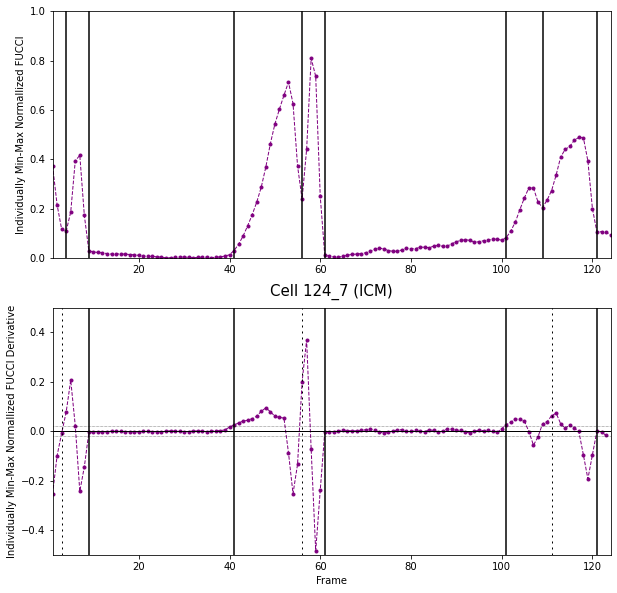

In [101]:
test_calls = annotate_trace(indiv_norm_traces, indiv_norm_derivs, [124, 7], makeplots = True)

In [102]:
make_all_anno_plots = False # make plots full annotation plots for all cells

if make_all_anno_plots:
    for indiv_fate in fate_data:
        for cell in indiv_fate[1]:
            test_calls = annotate_trace(indiv_norm_traces, indiv_norm_derivs, cell[0], makeplots = True, savefig = [True, plot_path, 'png'])

#### Get all automatic calls and save them to a CSV

In [103]:
all_calls = []
all_cells = []
for indiv_fate in fate_data:
    for cell in indiv_fate[1]:
        test_calls = annotate_trace(indiv_norm_traces, indiv_norm_derivs, cell[0], makeplots = False)
        all_calls.append(test_calls)
        all_cells.append(cell[0])
        print(cell[0], '>>', test_calls)

[124, 12] >> [[35, 79], [43, 91], [49, 101]]
[124, 42] >> [[37, 85], [47, 98], [53, 109]]
[124, 34] >> [[37, 86], [47, 98], [53, 111]]
[124, 54] >> [[37, 90], [47, 97], [53, 107]]
[124, 30] >> [[37, 90], [47, 97], [53, 107]]
[124, 203] >> [[41, 96], [53, 103], [61, 122]]
[124, 205] >> [[41, 96], [53, 103], [61]]
[124, 5] >> [[49, 89], [53, 101], [59, 114]]
[124, 17] >> [[49, 89], [53, 101], [59, 114]]
[124, 26] >> [[86], [46, 97], [52, 107]]
[124, 21] >> [[86], [46, 98], [52, 106]]
[124, 7] >> [[41, 101], [4, 56, 109], [9, 61, 121]]
[124, 35] >> [[40, 91], [4, 56, 104], [9, 61, 116]]
[124, 11] >> [[40, 91], [4, 56, 104], [9, 61, 115]]
[124, 9] >> [[35, 86], [3, 43, 90], [9, 48, 101]]
[124, 6] >> [[1, 43], [7, 50, 102], [13, 55, 119]]
[124, 204] >> [[1, 43], [7, 50, 102], [13, 55, 117]]
[124, 29] >> [[1, 43], [7, 50, 112], [13, 55]]
[124, 33] >> [[1, 43], [7, 50, 112], [13, 55, 120]]
[124, 4] >> [[1, 50], [7, 54, 110], [13, 59]]
[124, 23] >> [[1, 50], [7, 54, 109], [13, 59, 121]]
[124, 

In [104]:
def label_annotations(events, last_division = 64): # transforms list of trace annotations into labeled cell cycle phases
    new_events = copy.deepcopy(events)
    stage_events = [str(last_division) + 'cellstage']
    mitosis = 0
    
    if len(events[1]) > 0:
        mitosis = events[1][len(events[1]) - 1]
        stage_events.append(mitosis)
        new_events[1].pop(len(events[1]) - 1)
    
    if len(events[2]) > 0:
        g1_tmp = 999
        for event in events[2]:
            if (event > mitosis) and ((event - mitosis) < (g1_tmp - mitosis)):
                g1_tmp = event
        if g1_tmp < 999:
            g1 = g1_tmp
            stage_events.append(g1)
            new_events[2].pop(new_events[2].index(g1))
      
    if len(events[0]) > 0:
        g2_tmp = 999
        for event in events[0]:
            if (event > mitosis) and ((event - mitosis) < (g2_tmp - mitosis)):
                g2_tmp = event
        if g2_tmp < 999:
            g2 = g2_tmp
            stage_events.append(g2)
            new_events[0].pop(new_events[0].index(g2))
    
    if len(stage_events) == 1:
        out = []
    else:
        out = label_annotations(new_events, int(last_division / 2))
        out.append(stage_events)
        
    return out

In [105]:
annotations = []
for calls in all_calls:
    tmp = label_annotations(calls)
    annotations.append(tmp)
    print(tmp)

[['16cellstage', 35], ['32cellstage', 43, 49, 79], ['64cellstage', 91, 101]]
[['16cellstage', 37], ['32cellstage', 47, 53, 85], ['64cellstage', 98, 109]]
[['16cellstage', 37], ['32cellstage', 47, 53, 86], ['64cellstage', 98, 111]]
[['16cellstage', 37], ['32cellstage', 47, 53, 90], ['64cellstage', 97, 107]]
[['16cellstage', 37], ['32cellstage', 47, 53, 90], ['64cellstage', 97, 107]]
[['16cellstage', 41], ['32cellstage', 53, 61, 96], ['64cellstage', 103, 122]]
[['16cellstage', 41], ['32cellstage', 53, 61, 96], ['64cellstage', 103]]
[['16cellstage', 49], ['32cellstage', 53, 59, 89], ['64cellstage', 101, 114]]
[['16cellstage', 49], ['32cellstage', 53, 59, 89], ['64cellstage', 101, 114]]
[['32cellstage', 46, 52, 86], ['64cellstage', 97, 107]]
[['32cellstage', 46, 52, 86], ['64cellstage', 98, 106]]
[['16cellstage', 4, 9, 41], ['32cellstage', 56, 61, 101], ['64cellstage', 109, 121]]
[['16cellstage', 4, 9, 40], ['32cellstage', 56, 61, 91], ['64cellstage', 104, 116]]
[['16cellstage', 4, 9, 40],

In [106]:
anno_writer = []
counter = 0
for anno in annotations:
    new_anno = [str(all_cells[counter][0]) + '_' + str(all_cells[counter][1])]
    if len(anno) < 3:
        new_anno =  [str(all_cells[counter][0]) + '_' + str(all_cells[counter][1]), -1, -1, -1]
    cnt = 0
    for stage in anno:
        if cnt == 0:
            for i in range(4 - len(stage)):
                new_anno.append(-1)
        for i in range(len(stage) - 1):
            new_anno.append(stage[i + 1])
        if cnt == len(anno) - 1:
            for i in range(4 - len(stage)):
                new_anno.append(-1)
        cnt += 1
    anno_writer.append(new_anno)
    print(new_anno)
    counter += 1

['124_12', -1, -1, 35, 43, 49, 79, 91, 101, -1]
['124_42', -1, -1, 37, 47, 53, 85, 98, 109, -1]
['124_34', -1, -1, 37, 47, 53, 86, 98, 111, -1]
['124_54', -1, -1, 37, 47, 53, 90, 97, 107, -1]
['124_30', -1, -1, 37, 47, 53, 90, 97, 107, -1]
['124_203', -1, -1, 41, 53, 61, 96, 103, 122, -1]
['124_205', -1, -1, 41, 53, 61, 96, 103, -1, -1]
['124_5', -1, -1, 49, 53, 59, 89, 101, 114, -1]
['124_17', -1, -1, 49, 53, 59, 89, 101, 114, -1]
['124_26', -1, -1, -1, 46, 52, 86, 97, 107, -1]
['124_21', -1, -1, -1, 46, 52, 86, 98, 106, -1]
['124_7', 4, 9, 41, 56, 61, 101, 109, 121, -1]
['124_35', 4, 9, 40, 56, 61, 91, 104, 116, -1]
['124_11', 4, 9, 40, 56, 61, 91, 104, 115, -1]
['124_9', 3, 9, 35, 43, 48, 86, 90, 101, -1]
['124_6', -1, -1, 1, 7, 13, 43, 50, 55, 102, 119, -1]
['124_204', -1, -1, 1, 7, 13, 43, 50, 55, 102, 117, -1]
['124_29', -1, -1, 1, 7, 13, 43, 50, 55, 112, -1, -1]
['124_33', -1, -1, 1, 7, 13, 43, 50, 55, 112, 120, -1]
['124_4', -1, -1, 1, 7, 13, 50, 54, 59, 110, -1, -1]
['124_23',

In [107]:
out_file = os.path.join(stack_path, 'annotations.csv')
with open(out_file, 'w', newline='') as csvfile:
    csv_writer = csv.writer(csvfile)
    csv_writer.writerows(anno_writer)

#### Note: Some annotations require manual horizontal shifts in the CSV